In [ ]:
# Thach Ta

# Lab 6

You are tasked with evaluating card counting strategies for black jack. In order to do so, you will use object oriented programming to create a playable casino style black jack game where a computer dealer plays against $n$ computer players and possibily one human player. If you don't know the rules of blackjack or card counting, please google it. 

A few requirements:
* The game should utilize multiple 52-card decks. Typically the game is played with 6 decks.
* Players should have chips.
* Dealer's actions are predefined by rules of the game (typically hit on 16). 
* The players should be aware of all shown cards so that they can count cards.
* Each player could have a different strategy.
* The system should allow you to play large numbers of games, study the outcomes, and compare average winnings per hand rate for different strategies.

1. Begin by creating a classes to represent cards and decks. The deck should support more than one 52-card set. The deck should allow you to shuffle and draw cards. Include a "plastic" card, placed randomly in the deck. Later, when the plastic card is dealt, shuffle the cards before the next deal.

In [13]:
# Blackjack game is to get as close to 21 as possible without exceeding 21
# Dealer gives 2 cards to each player
# Players bet their chips
# Then, the player(s) "hit" or "stand" to receive more cards or play their hand

# Cards:
# 2-10; JQK; A
# Hearts, Diamonds, Spades, Clubs

# Value (JQK = 10, 2-10 are their respective values)
   # > Aces are either 1 OR 11.
     # They are 11 as long as the hand value doesn't exceed 21, but if it does, then they valued at 1

# Since a plastic card indicates when a deck should be shuffled, I'm planning on using indices

# Importing random for shuffling
import random

# First, I'll initialize a card class to refer its own value, suit, and rank:
class Card:
    def __init__(self, suit, rank):
        self.suit = suit
        self.rank = rank
        
        # Assigning values for each representation
        # All face cards have the same value:
        if rank in ["J", "Q", "K"]:
            self.value = 10
            
        # Aces will default on a value of 11 for now.
        # Later in the "Hand" class, we'll set a condition that if the hand's value > 21, aces have a self.value of 1
        elif rank == "A":
            self.value = 11
            
        # The number representations will be turned into integers and set as their self values
        else:
            self.value = int(rank)
    
    # Gives string representaiton of card
    def __repr__(self):
        return f"{self.rank} of {self.suit}"
    
# Now I'll initialize the Deck class with multiple decks
class Deck:
    def __init__(self, num_decks=6):
        self.num_decks = num_decks
        self.cards = []
        
        # Representing each card value & suit
        suits = ["Hearts", "Diamonds", "Clubs", "Spades"]
        ranks = ["2", "3", "4", "5", "6", "7", "8", "9", "10", "J", "Q", "K", "A"]
        
        # Creating multiple decks that gets cards assigned their suits and ranks:
        for d in range(num_decks):
            for suit in suits:
                for rank in ranks:
                    self.cards.append(Card(suit, rank))
                    
        self.shuffle()
        
        # Placing plastic card randomly within each deck:
        self.set_plastic_card()
        
    # Function for shuffling deck
    def shuffle(self):
        random.shuffle(self.cards)
    
    # Function for setting the plastic card
    def set_plastic_card(self):
        # We'll count the total amount of cards
        # This is so we can set the plastic card at a percentage towards the end of a deck
        total_cards = len(self.cards)
        start = int(total_cards * 0.75)
        end = total_cards - 1
        
        # This sets the card randomly within the index between the upper and lower boundaries we made
        self.plastic_card_index = random.randint(start, end)
        
    # Function for draiwng a card
    def draw_card(self):
        # If the number of cards counted is 0, we shuffle them
        if len(self.cards) == 0:
            print("Empty deck. Reshuffling.")
            self.__init__(self.num_decks)
        
        # pop(0) removes the first item and returns it to simulate drawing from the top of the deck
        # Also prevents duplicate objects
        card = self.cards.pop(0)
        
        return card
    
    # Function to determine when we reach the plastic card to start the shuffle
    def plastic_hit(self):
        return len(self.cards) <= self.plastic_card_index
    
    # Function to reset the deck
    def reset_deck(self):
        print("Reshuffling new deck...")
        self.__init__(self.num_decks)

In [20]:
# Test cell
deck = Deck(num_decks=2)

for i in range(10):
    card = deck.draw_card()
    print(card)

print("Cards left:", len(deck.cards))
print("Plastic card at:", deck.plastic_card_index)
print("Did we hit the plastic card?", deck.plastic_hit())

5 of Diamonds
7 of Spades
2 of Hearts
9 of Clubs
2 of Clubs
5 of Clubs
10 of Hearts
5 of Diamonds
K of Clubs
4 of Diamonds
Cards left: 94
Plastic card at: 86
Did we hit the plastic card? False


2. Now design your game on a UML diagram. You may want to create classes to represent, players, a hand, and/or the game. As you work through the lab, update your UML diagram. At the end of the lab, submit your diagram (as pdf file) along with your notebook. 

In [6]:
# Updated as I go through the lab

# Initial thought process:
# Game controls everything and has:
# -> Deck, Dealer, Players
# Player has:
# -> Hand
# Dealer has:
# -> Hand
# And each hand has:
# -> Card
# (UML Diagram submitted in .pdf file alongside notebook file)


# Game
# -----
# deck:Deck
# dealer:Dealer
# players:list[Player]
# count
# verbose
# -----
# setup_round(); Set-up for blackjack
# update_count(); Updating count for certain strategies
# deal_cards(); Dealing the first two cards
# player_turns(); Player's decision
# dealer_turn(); Dealer decision according to rules
# resolve_round(); Determines winners and updates chips
# player_game(); Running rounds


# Card
# -----
# suit
# rank
# value
# -----
# __repr__(); representing its own value


# Deck
# -----
# cards
# num_decks
# plastic_card_index
# -----
# shuffle(); shuffling a deck
# set_plastic_card(); putting in the plastic card for shuffle
# draw_card(); player hitting
# plastic_hit(); indicating when we need to shuffle
# reset_deck(); resetting deck


# Hand
# -----
# cards
# -----
# add_card(); adding card into hand
# get_value(); finding the value of the hand
# is_bust(); determining if hand's value is > 21
# clear(); clearing/emptying hand


# Player (Base Class)
# -----
# hand:Hand
# chips
# bet
# -----
# place_bet(); setting bet
# decide_action(); deciding to hit/stand
# win_bet(); winning
# lose_bet(); losing
# tie_bet(); tie


# HumanPlayer:Player
# -----
# decide_action(); action of this strategy


# DealerStrategyPlayer:Player
# -----
# decide_action(); action of this strategy


# CountingPlayer:Player
# -----
# threshold
# -----
# decide_action(); action of this strategy


# PowerPlayer:Player
# -----
# threshold
# -----
# decide_action(); action of this strategy


# Dealer
# -----
# hand:Hand
# -----
# play_turn(); dealer hits until rules say stop

3. Begin with implementing the skeleton (ie define data members and methods/functions, but do not code the logic) of the classes in your UML diagram.

In [5]:
# NOT updated as I go through the lab

# Explanations of each function are listed in the cell above
# More detailed explanation of the logic will be provided when the logic is coded
# -------------------------
# Card
# -------------------------
class Card:
    def __init__(self, suit, rank):
        self.suit = suit
        self.rank = rank
        self.value = 0
        
    def __repr__(self):
        pass

# -------------------------
# Deck
# -------------------------
class Deck:    
    def __init__(self, num_decks=6):
        self.num_decks = num_decks
        self.cards = []
        self.plastic_card_index = 0
    
    def shuffle(self):
        pass
    
    def set_plastic_card(self):
        pass
    
    def draw_card(self):
        pass
    
    def plastic_hit(self):
        pass
    
    def reset_deck(self):
        pass

# -------------------------
# Hand
# -------------------------
class Hand:
    def __init__(self):
        self.cards = []
        
    def add_card(self, card):
        pass
    
    def get_value(self):
        pass
    
    def is_bust(self):
        pass
    
    def clear(self):
        pass

# -------------------------
# Player
# -------------------------
class Player:
    def __init__(self, chips=100):
        self.hand = Hand()
        self.chips = chips
        self.bet = 0
        
    def place_bet(self):
        pass
    
    def decide_action(self):
        pass
    
    def win_bet(self):
        pass
    
    def lose_bet(self):
        pass
    
    def tie_bet(self):
        pass

# -------------------------
# Dealer
# -------------------------
class Dealer:
    def __init__(self):
        self.hand = Hand()
        
    def play_turn(self, deck):
        pass

# -------------------------
# Game
# -------------------------
class Game:
    def __init__(self, players):
        self.deck = Deck()
        self.dealer = Dealer()
        self.players = players
        
    def setup_round(self):
        pass
    
    def deal_cards(self):
        pass
    
    def player_turns(self):
        pass
    
    def dealer_turn(self):
        pass
    
    def resolve_round(self):
        pass
    
    def play_game(self, rounds=1):
        pass

# -------------------------
# HumanPlayer
# -------------------------
class HumanPlayer(Player):
    
    def decide_action(self):
        pass
    
# -------------------------
# RobotPlayer
# -------------------------
class RobotPlayer(Player):
    
    def decide_action(self):
        pass

4. Complete the implementation by coding the logic of all functions. For now, just implement the dealer player and human player.

In [28]:
import random


# -------------------------
# Card
# -------------------------
class Card:
    def __init__(self, suit, rank):
        self.suit = suit
        self.rank = rank
        if rank in ["J", "Q", "K"]:
            self.value = 10
            
        elif rank == "A":
            self.value = 11
            
        else:
            self.value = int(rank)
    
    def __repr__(self):
        return f"{self.rank} of {self.suit}"

# -------------------------
# Deck
# -------------------------
class Deck:
    def __init__(self, num_decks=6):
        self.num_decks = num_decks
        self.cards = []
        
        suits = ["Hearts", "Diamonds", "Clubs", "Spades"]
        ranks = ["2", "3", "4", "5", "6", "7", "8", "9", "10", "J", "Q", "K", "A"]
        
        for d in range(num_decks):
            for suit in suits:
                for rank in ranks:
                    self.cards.append(Card(suit, rank))
                    
        self.shuffle()
        self.set_plastic_card()
        
    def shuffle(self):
        random.shuffle(self.cards)
    
    def set_plastic_card(self):
        total_cards = len(self.cards)
        start = int(total_cards * 0.75)
        end = total_cards - 1
        
        self.plastic_card_index = random.randint(start, end)
        
    def draw_card(self):
        if len(self.cards) == 0:
            print("Empty deck. Reshuffling.")
            self.__init__(self.num_decks)

        card = self.cards.pop(0)  
        return card
    
    def plastic_hit(self):
        return len(self.cards) <= self.plastic_card_index
    
    def reset_deck(self):
        print("Reshuffling new deck...")
        self.__init__(self.num_decks)
        
        
# -------------------------
# Hand
# -------------------------
class Hand:
    def __init__(self):
        # Cards are held in a list
        self.cards = []
    
    # Appending the cards into the list
    def add_card(self, card):
        self.cards.append(card)
    
    # Setting value count
    def get_value(self):
        total = 0
        # Separate counter for aces to dynamically go between +1 and +11
        aces = 0
        
        # Ace counter
        for card in self.cards:
            total += card.value
            if card.rank == "A":
                aces += 1
            
        # Aces will be +11, but if the total adds up greater than 21
        # Then aces will be +1
        while total > 21 and aces > 0:
            total -= 10
            aces -= 1
        
        return total
    
    # If score is over 21, you lose (bust)
    def is_bust(self):
        return self.get_value() > 21
    
    # Clearing hand
    def clear(self):
        self.cards = []

# -------------------------
# Player
# -------------------------
# Base class for both human and different strategy robot players

class Player:
    # Initializing the currency held
    def __init__(self, chips=100):
        # Giving the cards to make a hand and storing values
        self.hand = Hand()
        self.chips = chips
        self.bet = 0
    
    # Betting action
    def place_bet(self):
        self.bet = 10
        self.chips -= self.bet
    
    # This function will be overridden depending on if the player is human or robot
    # Updated for step 6 for counting cards, where every action updates the count
    def decide_action(self, count=None):
        pass
    
    # Updating currency when winnning
    def win_bet(self):
        self.chips += 2 * self.bet
    
    # No currency won when lost
    def lose_bet(self):
        pass
    
    # Regaining back the chips bet when in a tie
    def tie_bet(self):
        self.chips += self.bet

# -------------------------
# Dealer
# -------------------------
class Dealer:
    def __init__(self):
        # Giving the dealer a hand
        self.hand = Hand()
    
    # While the hand is < 17, the dealer will hit (Typically hitting on 16)
    def play_turn(self, deck):
        while self.hand.get_value() < 17:
            self.hand.add_card(deck.draw_card())

# -------------------------
# Game
# -------------------------
class Game:
    def __init__(self, players):
        # Game will track the count of cards since all players will "see" the same cards
        self.count = 0
        # Setting the game's units and decks
        self.deck = Deck()
        self.dealer = Dealer()
        # We'll set players as a list to choose different functions, so we can test against different strategies
        self.players = players
        
    def setup_round(self):
        # Setting a round with a fresh hand for both dealer and players
        self.dealer.hand.clear()
        for player in self.players:
            player.hand.clear()
            player.place_bet()
    
    # Helper function for step 6
    def update_count(self, card):
        # Cards 2 to 6 are +1
        if card.rank in ["2", "3", "4", "5", "6"]:
            self.count += 1
        # Cards 10 through Ace are -1
        elif card.rank in ["10", "J", "Q", "K", "A"]:
            self.count -= 1
    
    def deal_cards(self):
        # Dealing two cards when hitting
        for _ in range(2):
            for player in self.players:
                # Updated to update counts in step 6
                card = self.deck.draw_card()
                player.hand.add_card(card)
                self.update_count(card)
                
            card = self.deck.draw_card()
            self.dealer.hand.add_card(card)
            self.update_count(card)
    
    def player_turns(self):
        for i, player in enumerate(self.players):
            # Displaying hand
            print(f"\n--- Player {i+1}'s Turn ---")
            print("Your hand:", player.hand.cards)
            print("Current value:", player.hand.get_value())
            
            # Lets player do an action as long as they haven't hit the lose condition
            while not player.hand.is_bust():
                # Updated for step 6. Action adds to count
                action = player.decide_action(self.count)
                
                # Draws 2 cards
                if action == "hit":
                    card = self.deck.draw_card()
                    player.hand.add_card(card)
                    
                    # Updated for step 6 to count cards
                    self.update_count(card)
                    
                    # Displaying action
                    print("You drew:", card)
                    print("Your hand:", player.hand.cards)
                    print("Current value:", player.hand.get_value())
                else:
                    break
            
            # Prints loss
            if player.hand.is_bust():
                print("Bust!")
        
        # Displays the current count
        print("Running count:", self.count)
    
    def dealer_turn(self):
        # Dealer turn function
        print("\n--- Dealer's Turn ---")
        # Display dealer hand
        print("Dealer hand:", self.dealer.hand.cards)
        
        # Plays the turn
        # Updated for step 6 by moving dealer logic into game to track count
        while self.dealer.hand.get_value() < 17:
            card = self.deck.draw_card()
            self.dealer.hand.add_card(card)
            self.update_count(card)
        
        # Shows the hand and its value
        print("Dealer final hand:", self.dealer.hand.cards)
        print("Dealer value:", self.dealer.hand.get_value())
    
    # When a round is over...
    def resolve_round(self):
        # Dealer shows the value of their hand
        dealer_value = self.dealer.hand.get_value()
        print("\n--- Round Results ---")
        print("Dealer value:", dealer_value)
        
        # Players show the values of their hands
        for i, player in enumerate(self.players):
            player_value = player.hand.get_value()
            print(f"\nPlayer {i+1} value:", player_value)
            
            # Win/lose/tie conditions
            if player.hand.is_bust():
                print("Busted... lose.")
                player.lose_bet()
            elif dealer_value > 21 or player_value > dealer_value:
                print("Win!")
                player.win_bet()
            elif player_value < dealer_value:
                print("Lose.")
                player.lose_bet()
            else:
                print("Tie.")
                player.tie_bet()
    
    # Function to play the game
    def play_game(self, rounds=1):
        for i in range(rounds):
            self.setup_round()
            self.deal_cards()
            self.player_turns()
            self.dealer_turn()
            self.resolve_round()
            
            # Refreshing deck in the game if the plastic card is hit
            if self.deck.plastic_hit():
                self.deck.reset_deck()
                # Updated for step 6 to reset counts
                self.count = 0
                
# ===================================
# DIFFERENT PLAYERS:
# ===================================
# -------------------------
# HumanPlayer
# -------------------------
# Updated for Step 6 to ignore count
class HumanPlayer(Player):
    
    # Function for the user to put inputs for hitting/standing
    def decide_action(self, count=None):
        while True:
            action = input("Hit or stand? (h/s): ").lower()
            if action == "h":
                return "hit"
            elif action == "s":
                return "stand"
            else:
                print("Invalid input. Try again.")

# -------------------------
# RobotPlayer: (Dealer strategy for Step 5)
# -------------------------
class DealerStrategyPlayer(Player):
    # Action follows dealer method
    # Updated for step 6 to ignore count
    def decide_action(self, count=None):
        # Hits if 16 or less
        if self.hand.get_value() < 17:
            return "hit"
        # Stands otherwise
        return "stand"
    
# -------------------------
# RobotPlayer: (Card counting strategy for Step 6)
# -------------------------
class CountingPlayer(Player):
    # Action that takes into account of count
    def decide_action(self, count):
        # If the sum of values is <= -2, then player will hit
        if count <= -2:
            return "hit"
        return "stand"

In [18]:
# Test cell

# Setting the list allows us to choose what type of players we want
players = [HumanPlayer()]

game = Game(players)
game.play_game(rounds=3)

print("\n Resulting chips:")
# For every player within the player list, print out the total amount of chips of each player
for i, player in enumerate(game.players):
    print(f"Player {i+1} chips:", player.chips)


--- Player 1's Turn ---
Your hand: [3 of Diamonds, K of Spades]
Current value: 13
Hit or stand? (h/s): h
You drew: Q of Clubs
Your hand: [3 of Diamonds, K of Spades, Q of Clubs]
Current value: 23
Bust!
Running count: -1

--- Dealer's Turn ---
Dealer hand: [3 of Hearts, A of Hearts]
Dealer final hand: [3 of Hearts, A of Hearts, 4 of Clubs]
Dealer value: 18

--- Round Results ---
Dealer value: 18

Player 1 value: 23
Busted... lose.

--- Player 1's Turn ---
Your hand: [5 of Hearts, 10 of Clubs]
Current value: 15
Hit or stand? (h/s): h
You drew: 7 of Diamonds
Your hand: [5 of Hearts, 10 of Clubs, 7 of Diamonds]
Current value: 22
Bust!
Running count: 2

--- Dealer's Turn ---
Dealer hand: [6 of Diamonds, 3 of Spades]
Dealer final hand: [6 of Diamonds, 3 of Spades, 7 of Diamonds, 9 of Diamonds]
Dealer value: 25

--- Round Results ---
Dealer value: 25

Player 1 value: 22
Busted... lose.

--- Player 1's Turn ---
Your hand: [9 of Diamonds, 2 of Hearts]
Current value: 11
Hit or stand? (h/s): h
Y

5.  Test. Demonstrate game play. For example, create a game of several dealer players and show that the game is functional through several rounds.

In [19]:
# DealerStrategyPlayer() made in coding cell above
players = [DealerStrategyPlayer(), DealerStrategyPlayer(), DealerStrategyPlayer()]

game = Game(players)
game.play_game(rounds=5)

print("\n Resulting chips:")
for i, player in enumerate(game.players):
    print(f"Player {i+1} chips:", player.chips)


--- Player 1's Turn ---
Your hand: [4 of Clubs, 7 of Hearts]
Current value: 11
You drew: 8 of Spades
Your hand: [4 of Clubs, 7 of Hearts, 8 of Spades]
Current value: 19

--- Player 2's Turn ---
Your hand: [5 of Clubs, J of Spades]
Current value: 15
You drew: K of Diamonds
Your hand: [5 of Clubs, J of Spades, K of Diamonds]
Current value: 25
Bust!

--- Player 3's Turn ---
Your hand: [A of Diamonds, 8 of Hearts]
Current value: 19
Running count: -1

--- Dealer's Turn ---
Dealer hand: [A of Hearts, 2 of Clubs]
Dealer final hand: [A of Hearts, 2 of Clubs, 5 of Clubs]
Dealer value: 18

--- Round Results ---
Dealer value: 18

Player 1 value: 19
Win!

Player 2 value: 25
Busted... lose.

Player 3 value: 19
Win!

--- Player 1's Turn ---
Your hand: [2 of Clubs, K of Hearts]
Current value: 12
You drew: J of Hearts
Your hand: [2 of Clubs, K of Hearts, J of Hearts]
Current value: 22
Bust!

--- Player 2's Turn ---
Your hand: [6 of Spades, A of Diamonds]
Current value: 17

--- Player 3's Turn ---
You

6. Implement a new player with the following strategy:

    * Assign each card a value: 
        * Cards 2 to 6 are +1 
        * Cards 7 to 9 are 0 
        * Cards 10 through Ace are -1
    * Compute the sum of the values for all cards seen so far.
    * Hit if sum is very negative, stay if sum is very positive. Select a threshold for hit/stay, e.g. 0 or -2.  

In [27]:
# Strategy:
# Cards 2-6: +1
# Cards 7-9: 0
# Cards 10-A: -1
# Positive sum -> GOOD
# Negative sum -> BAD

# If count <= -2 -> HIT
# If count >= 0 -> STAND

# Added "self.count = 0" in Game.__init__

# Test cell
players = [CountingPlayer(), DealerStrategyPlayer(), DealerStrategyPlayer()]
game = Game(players)
game.play_game(rounds=1)

print("\n Resulting chips:")
for i, player in enumerate(game.players):
    print(f"Player {i+1} chips:", player.chips)


--- Player 1's Turn ---
Your hand: [K of Clubs, 6 of Spades]
Current value: 16

--- Player 2's Turn ---
Your hand: [6 of Hearts, 5 of Diamonds]
Current value: 11
You drew: 2 of Hearts
Your hand: [6 of Hearts, 5 of Diamonds, 2 of Hearts]
Current value: 13
You drew: 7 of Diamonds
Your hand: [6 of Hearts, 5 of Diamonds, 2 of Hearts, 7 of Diamonds]
Current value: 20

--- Player 3's Turn ---
Your hand: [2 of Hearts, 4 of Hearts]
Current value: 6
You drew: 9 of Clubs
Your hand: [2 of Hearts, 4 of Hearts, 9 of Clubs]
Current value: 15
You drew: 7 of Clubs
Your hand: [2 of Hearts, 4 of Hearts, 9 of Clubs, 7 of Clubs]
Current value: 22
Bust!
Running count: 4

--- Dealer's Turn ---
Dealer hand: [A of Hearts, 9 of Hearts]
Dealer final hand: [A of Hearts, 9 of Hearts]
Dealer value: 20

--- Round Results ---
Dealer value: 20

Player 1 value: 16
Lose.

Player 2 value: 20
Tie.

Player 3 value: 22
Busted... lose.

 Resulting chips:
Player 1 chips: 90
Player 2 chips: 100
Player 3 chips: 90


7. Create a test scenario where one player, using the above strategy, is playing with a dealer and 3 other players that follow the dealer's strategy. Each player starts with same number of chips. Play 50 rounds (or until the strategy player is out of money). Compute the strategy player's winnings. You may remove unnecessary printouts from your code (perhaps implement a verbose/quiet mode) to reduce the output.

In [124]:
# Cleaned up code:

# Updated for step 7, where every print in:
# player_turns(), dealer_turn(), and resolve_round() 
# is wrapped with if self.verbose:
# To either enable or disable verbosity

# Chip tracking added in play_game()

import random


# -------------------------
# Card
# -------------------------
class Card:
    def __init__(self, suit, rank):
        self.suit = suit
        self.rank = rank
        if rank in ["J", "Q", "K"]:
            self.value = 10
            
        elif rank == "A":
            self.value = 11
            
        else:
            self.value = int(rank)
    
    def __repr__(self):
        return f"{self.rank} of {self.suit}"

# -------------------------
# Deck
# -------------------------
class Deck:
    def __init__(self, num_decks=6):
        self.num_decks = num_decks
        self.cards = []
        
        suits = ["Hearts", "Diamonds", "Clubs", "Spades"]
        ranks = ["2", "3", "4", "5", "6", "7", "8", "9", "10", "J", "Q", "K", "A"]
        
        for d in range(num_decks):
            for suit in suits:
                for rank in ranks:
                    self.cards.append(Card(suit, rank))
                    
        self.shuffle()
        self.set_plastic_card()
        
    def shuffle(self):
        random.shuffle(self.cards)
    
    def set_plastic_card(self):
        total_cards = len(self.cards)
        start = int(total_cards * 0.75)
        end = total_cards - 1
        
        self.plastic_card_index = random.randint(start, end)
        
    def draw_card(self):
        if len(self.cards) == 0:
            #print("Empty deck. Reshuffling.")
            self.__init__(self.num_decks)

        card = self.cards.pop(0)  
        return card
    
    def plastic_hit(self):
        return len(self.cards) <= self.plastic_card_index
    
    def reset_deck(self):
        #print("Reshuffling new deck...")
        self.__init__(self.num_decks)
        
# -------------------------
# Hand
# -------------------------
class Hand:
    def __init__(self):
        self.cards = []
    
    def add_card(self, card):
        self.cards.append(card)
    
    def get_value(self):
        total = 0
        aces = 0
        
        for card in self.cards:
            total += card.value
            if card.rank == "A":
                aces += 1
            
        while total > 21 and aces > 0:
            total -= 10
            aces -= 1
        
        return total
    
    def is_bust(self):
        return self.get_value() > 21
    
    def clear(self):
        self.cards = []

# -------------------------
# Player
# -------------------------
class Player:
    def __init__(self, chips=100):
        self.hand = Hand()
        self.chips = chips
        self.bet = 0
    
    def place_bet(self):
        self.bet = 10
        self.chips -= self.bet
    
    def decide_action(self, count=None):
        pass
    
    def win_bet(self):
        self.chips += 2 * self.bet
    
    def lose_bet(self):
        pass
    
    def tie_bet(self):
        self.chips += self.bet

# -------------------------
# Dealer
# -------------------------
class Dealer:
    def __init__(self):
        self.hand = Hand()
    
    def play_turn(self, deck):
        while self.hand.get_value() < 17:
            self.hand.add_card(deck.draw_card())

# -------------------------
# Game
# -------------------------
# Updated for step 7 for verbosity
class Game:
    def __init__(self, players, verbose=True):
        self.count = 0
        self.deck = Deck()
        self.dealer = Dealer()
        self.players = players
        self.verbose = verbose
        
    def setup_round(self):
        self.dealer.hand.clear()
        for player in self.players:
            player.hand.clear()
            player.place_bet()
    
    def update_count(self, card):
        if card.rank in ["2", "3", "4", "5", "6"]:
            self.count += 1
        elif card.rank in ["10", "J", "Q", "K", "A"]:
            self.count -= 1
    
    def deal_cards(self):
        for _ in range(2):
            for player in self.players:
                card = self.deck.draw_card()
                player.hand.add_card(card)
                self.update_count(card)
                
            card = self.deck.draw_card()
            self.dealer.hand.add_card(card)
            self.update_count(card)
    
    def player_turns(self):
        for i, player in enumerate(self.players):
            if self.verbose:
                print(f"\n--- Player {i+1}'s Turn ---")
                print("Your hand:", player.hand.cards)
                print("Current value:", player.hand.get_value())
            
            while not player.hand.is_bust():
                action = player.decide_action(self.count)
                
                if action == "hit":
                    card = self.deck.draw_card()
                    player.hand.add_card(card)
                    
                    self.update_count(card)
                    
                    if self.verbose:
                        print("You drew:", card)
                        print("Your hand:", player.hand.cards)
                        print("Current value:", player.hand.get_value())
                        
                else:
                    break
            
            if player.hand.is_bust():
                if self.verbose:
                    print("Bust!")
        
        #print("Running count:", self.count)
    
    def dealer_turn(self):
        if self.verbose:
            print("\n--- Dealer's Turn ---")
            print("Dealer hand:", self.dealer.hand.cards)
        
        while self.dealer.hand.get_value() < 17:
            card = self.deck.draw_card()
            self.dealer.hand.add_card(card)
            self.update_count(card)
        
        if self.verbose:
            print("Dealer final hand:", self.dealer.hand.cards)
            print("Dealer value:", self.dealer.hand.get_value())
    
    def resolve_round(self):
        dealer_value = self.dealer.hand.get_value()
        
        if self.verbose:
            print("\n--- Round Results ---")
            print("Dealer value:", dealer_value)
        
        for i, player in enumerate(self.players):
            player_value = player.hand.get_value()
            
            if self.verbose:
                print(f"\nPlayer {i+1} value:", player_value)
            
            if player.hand.is_bust():
                if self.verbose:
                    print("Busted... lose.")
                player.lose_bet()
            elif dealer_value > 21 or player_value > dealer_value:
                if self.verbose:
                    print("Win!")
                player.win_bet()
            elif player_value < dealer_value:
                if self.verbose:
                    print("Lose.")
                player.lose_bet()
            else:
                if self.verbose:
                    print("Tie.")
                    player.tie_bet()
    
    def play_game(self, rounds=1):
        # List storing chip values
        history = []
        
        # This tracks THE FIRST player
        strategy_player = self.players[0]
        start_chips = strategy_player.chips
        
        for i in range(rounds):
            # Stops if player is broke
            if strategy_player.chips <= 0:
                break
            
            self.setup_round()
            self.deal_cards()
            self.player_turns()
            self.dealer_turn()
            self.resolve_round()
            
            # Tracks winnings
            current = strategy_player.chips - start_chips
            history.append(current)
            
            if self.deck.plastic_hit():
                self.deck.reset_deck()
                self.count = 0
                
        return history
                
# ===================================
# DIFFERENT PLAYERS:
# ===================================
# -------------------------
# HumanPlayer
# -------------------------
class HumanPlayer(Player):
    
    def decide_action(self, count=None):
        while True:
            action = input("Hit or stand? (h/s): ").lower()
            if action == "h":
                return "hit"
            elif action == "s":
                return "stand"
            else:
                print("Invalid input. Try again.")

# -------------------------
# RobotPlayer: (Dealer strategy for Step 5)
# -------------------------
class DealerStrategyPlayer(Player):
    def decide_action(self, count=None):
        if self.hand.get_value() < 17:
            return "hit"
        return "stand"
    
# -------------------------
# RobotPlayer: (Card counting strategy for Step 6)
# -------------------------
# Updated for step 9 to change thresholds
class CountingPlayer(Player):
    def __init__(self, threshold=-2):
        # Learned about super() online to be able to have a subclass inheritance
        super().__init__()
        self.threshold = threshold
    
    def decide_action(self, count):
        if count <= self.threshold:
            return "hit"
        return "stand"

# -------------------------
# RobotPlayer: (Power player for step 10)
# -------------------------
# We'll be more aggressive with more negative values while being more passive with positive values
# Uses the same counting system as the counter player
class PowerPlayer(Player):
    def __init__(self, threshold=-2):
        super().__init__()
        self.threshold = threshold
    
    def decide_action(self, count):
        value = self.hand.get_value()
        
        if value <= 11:
            return "hit"
        if value >= 17:
            return "stand"
        
        # Middle zone that depends on the count more
        if 12 <= value <= 16:
            if count <= self.threshold:
                # Bad deck, take risk
                return "hit"
            else:
                # Good deck, stay safe
                return "stand"
        
        return "stand"

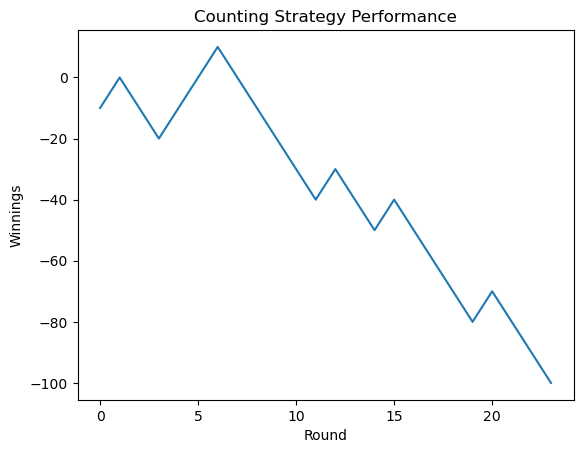

Final winnings: -100


In [111]:
# Test scenario:
# 1 player using counting strategy
# Playing w/ a dealer & 3 other players using the dealer strategy
# Play 50 rounds (or until strategy player is out of money)

# Importing matplotlib for plotting
import matplotlib.pyplot as plt

players = [
    CountingPlayer(),
    DealerStrategyPlayer(),
    DealerStrategyPlayer(),
    DealerStrategyPlayer()
]

# Quiet mode
game = Game(players, verbose=False)
winnings = game.play_game(rounds=50)

plt.figure()
plt.plot(winnings)
plt.xlabel("Round")
plt.ylabel("Winnings")
plt.title("Counting Strategy Performance")
plt.show()

print("Final winnings:", winnings[-1])

8. Create a loop that runs 100 games of 50 rounds, as setup in previous question, and store the strategy player's chips at the end of the game (aka "winnings") in a list. Histogram the winnings. What is the average winnings per round? What is the standard deviation. What is the probabilty of net winning or lossing after 50 rounds?


In [116]:
# Winnings list:
results = []

# Setting loop for 100 games and 50 rounds
num_games = 100
rounds_per_game = 50

for i in range(num_games):
    players = [
        CountingPlayer(),
        DealerStrategyPlayer(),
        DealerStrategyPlayer(),
        DealerStrategyPlayer()
    ]
    
    # Keeping the game silent to not flood the result cell
    game = Game(players, verbose=False)
    winnings_history = game.play_game(rounds=rounds_per_game)
    
    # Final winnings after 50 rounds
    final_winnings = winnings_history[-1]
    results.append(final_winnings)

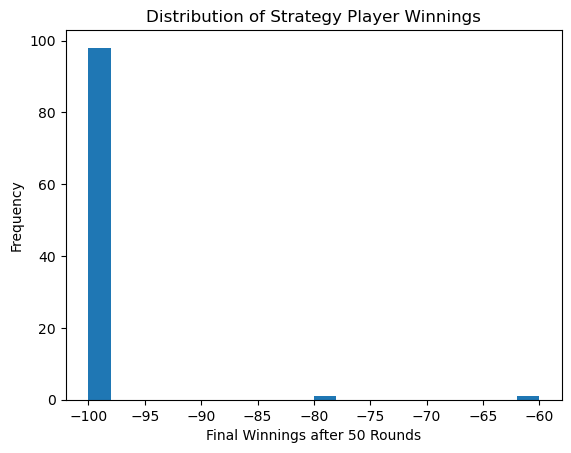

Average winnings per game: -99.4
Average winnings per round: -1.9880000000000002
Standard deviation: 4.431703961232068
Probability of winning: 0.0
Probability of losing: 1.0


In [117]:
# Plotting the histogram
plt.figure()
plt.hist(results, bins=20)
plt.xlabel("Final Winnings after 50 Rounds")
plt.ylabel("Frequency")
plt.title("Distribution of Strategy Player Winnings")
plt.show()

# Average winnings = Sum of the results / Number of results
avg_winnings = sum(results) / len(results)
# Average per round = Average of the winnings / Rounds per game
avg_per_round = avg_winnings / rounds_per_game
print("Average winnings per game:", avg_winnings)
print("Average winnings per round:", avg_per_round)

mean = avg_winnings

# Coding variance formula
variance = 0
for x in results:
    variance += (x - mean) ** 2

variance = variance / len(results)
# Standard deviation is variance squared aka ^0.5
std_dev = variance ** 0.5
print("Standard deviation:", std_dev)

wins = 0
losses = 0

for x in results:
    if x > 0:
        wins += 1
    elif x < 0:
        losses += 1
        
# Probability calculation
prob_win = wins / len(results)
prob_loss = losses / len(results)
print("Probability of winning:", prob_win)
print("Probability of losing:", prob_loss)

9. Repeat previous questions scanning the value of the threshold. Try at least 5 different threshold values. Can you find an optimal value?

In [118]:
# CountingPlayer class updated to change thresholds

# Threshold list to modify
thresholds = [-45, -44, -43, -42, -41]
threshold_results = {}

# 100 games, 50 rounds, but this loop uses different thresholds listed above
for t in thresholds:
    results = []
    
    for i in range(100):
        players = [
            CountingPlayer(threshold=t),
            DealerStrategyPlayer(),
            DealerStrategyPlayer(),
            DealerStrategyPlayer()
        ]
        
        game = Game(players, verbose=False)
        winnings_history = game.play_game(rounds=50)
        results.append(winnings_history[-1])
    
    # Computing average
    avg = sum(results) / len(results)
    threshold_results[t] = avg

Threshold: -45 Average Winnings: -83.4
Threshold: -44 Average Winnings: -83.6
Threshold: -43 Average Winnings: -82.2
Threshold: -42 Average Winnings: -84.2
Threshold: -41 Average Winnings: -82.4


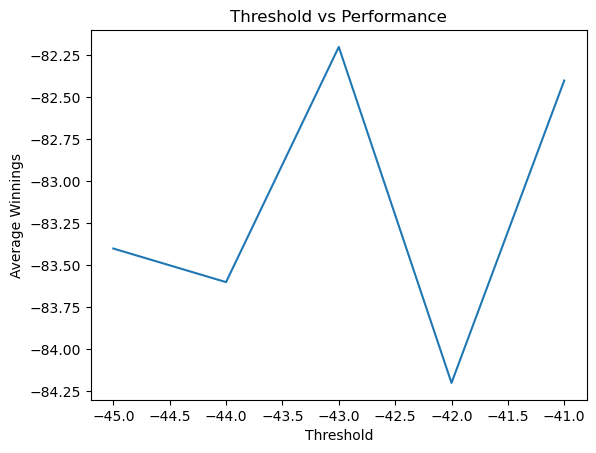

Best threshold: -43


In [119]:
# Printing results
for t in threshold_results:
    print("Threshold:", t, "Average Winnings:", threshold_results[t])

# Plotting results
x = list(threshold_results.keys())
y = list(threshold_results.values())

plt.figure()
plt.plot(x, y)
plt.xlabel("Threshold")
plt.ylabel("Average Winnings")
plt.title("Threshold vs Performance")
plt.show()

# Best threshold should have the best average winnings
best = max(threshold_results, key=threshold_results.get)
print("Best threshold:", best)

In [1]:
# After consistently running the game over and over again and narrowing the threshold intervals...
# It seems -43 as a threshold seems to work the best.
# This seems... odd, but I don't want to spend more time to fix this

10. Create a new strategy based on web searches or your own ideas. Demonstrate that the new strategy will result in increased or decreased winnings. 

Counting avg: -99.0
Power avg: -64.2


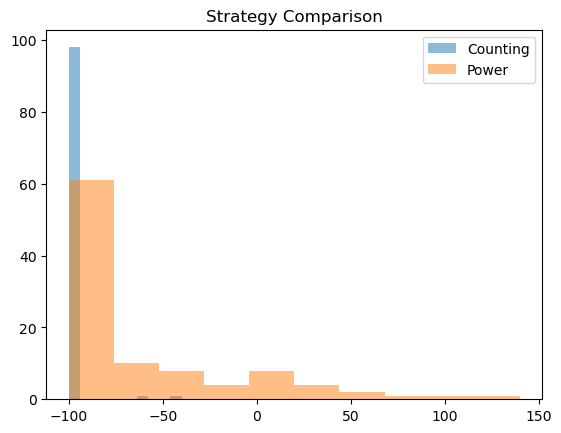

In [130]:
# PowerPlayer coded in main coding cell above
# Follows basic blackjack rules
# With count: 
# If count is very negative, be more aggressive (hit more)
# If count is positive, be more passive (stand more)

# Simulation to run 100 games, 50 rounds each
def run_simulation(player_class, threshold=-2):
    results = []
    
    for i in range(100):
        players = [
            player_class(threshold),
            DealerStrategyPlayer(),
            DealerStrategyPlayer(),
            DealerStrategyPlayer()
        ]
        
        game = Game(players, verbose=False)
        winnings = game.play_game(rounds=50)
        results.append(winnings[-1])
    
    return results

# Results
counting_results = run_simulation(CountingPlayer, -2)
power_results = run_simulation(PowerPlayer, -2)

# Calculating averages
avg_counting = sum(counting_results) / len(counting_results)
avg_power = sum(power_results) / len(power_results)

# Printing results
print("Counting avg:", avg_counting)
print("Power avg:", avg_power)

plt.figure()
plt.hist(counting_results, alpha=0.5, label="Counting")
plt.hist(power_results, alpha=0.5, label="Power")
plt.legend()
plt.title("Strategy Comparison")
plt.show()

In [2]:
# PowerPlayer() seems to be running a lot more consistent and winning a lot more often
# The average is odd much like earlier, but at least it seems to be greater than counting alone